---
tags: [algorithm, primitive, simulation]
---

# Hamiltonian Simulation with Suzuki–Trotter (Rabi oscillation)

Simulating the time evolution $e^{-iHt}$ of a quantum system is one of the
canonical applications of a quantum computer. When the Hamiltonian splits
into non-commuting pieces $H = A + B$ with $[A, B] \neq 0$, the naive
factorisation $e^{-i(A+B)t} = e^{-iAt}\,e^{-iBt}$ is wrong. Instead, we use
approximations commonly called **Suzuki-Trotter product formulas**, which
interleave short evolutions of each term. The approximation error
(Trotter error) decreases as the approximation order increases. The
first-order case is the Lie-Trotter product formula
{cite:p}`10.1090/S0002-9939-1959-0108732-6`, and higher-order recursive
formulas are given by the Suzuki-Trotter product-formula construction
{cite:p}`10.1007/BF01609348`.

This article uses a one-qubit Rabi-oscillation Hamiltonian, where the
Trotter error is easy to measure, and shows how to implement Hamiltonian
simulation with Trotter decomposition in Qamomile. We cover two
implementations: a scratch implementation and a simpler version using the
built-in `trotterized_time_evolution` function. We then run the implemented
quantum circuits and check their convergence rates ($S_k$'s fidelity error
scales as $\Delta t^{2k}$) against an exact reference.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]"

In [2]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm import trotterized_time_evolution
from qamomile.qiskit import QiskitTranspiler

## Problem Settings: Rabi Oscillation

We use the smallest non-trivial Hamiltonian simulation problem: one qubit
with two non-commuting Hamiltonian terms. This keeps the circuits compact
while still making the Trotter error visible.

### Hamiltonian

A single two-level system driven on resonance is governed by

$$ H = \underbrace{\tfrac{\omega}{2} Z}_{H_z} + \underbrace{\tfrac{\Omega}{2} X}_{H_x}. $$

Because $[Z, X] \neq 0$, splitting $H$ into $H_z$ and $H_x$ introduces a
Trotter error that is easy to see even on a single qubit. Starting from
$|0\rangle$, the excitation probability oscillates as
$P_{|1\rangle}(t) = (\Omega/E)^2 \sin^2(Et/2)$ with $E = \sqrt{\omega^2 + \Omega^2}$.

In Qamomile we build $H_z$ and $H_x$ as two separate `Observable`s and pack
them into a Python list. A `@qkernel` declares that list as
`Vector[Observable]`; binding the list at transpile time expands any
iteration over `Hs.shape[0]` into per-term `pauli_evolve` calls.

In [3]:
omega = 1.2
Omega = 0.8
T = 1.5

Hz = 0.5 * omega * qm_o.Z(0)
Hx = 0.5 * Omega * qm_o.X(0)
Hs = [Hz, Hx]

### Verifying $[H_z, H_x] \neq 0$

Trotter approximations only matter because $H_z$ and $H_x$ do not commute.
`qamomile.observable.commutator(a, b)` computes the commutator
$[a, b] = a b - b a$ on Hamiltonians directly. Internally it iterates over
the Pauli-string pairs once and uses the qubit-parity rule — two Pauli
strings anticommute iff the number of qubits on which they carry different
non-identity Paulis is odd — to drop every commuting pair before any
product is built. This is cheaper than expanding `Hz * Hx - Hx * Hz` and
cancelling, and the result is a fully simplified `Hamiltonian` that we can
inspect or compare against an analytic value.

For the Rabi Hamiltonian the textbook value is

$$ [H_z, H_x] \;=\; \tfrac{\omega \Omega}{4}\,[Z, X] \;=\; i\,\tfrac{\omega \Omega}{2}\, Y, $$

which `commutator` reproduces exactly:

In [4]:
comm_zx = qm_o.commutator(Hz, Hx)
print(comm_zx)

expected = 1j * 0.5 * omega * Omega * qm_o.Y(0)
assert comm_zx == expected

Hamiltonian((Y0,): 0.48j)


### Exact reference state

A dense 2x2 matrix exponential gives the exact state
$|\psi(T)\rangle = e^{-iHT}|0\rangle$ directly. This is simpler than
asking a quantum SDK to simulate the one-qubit reference state, and it is
also the object against which each Trotter approximation is judged via the
**fidelity error** $1 - |\langle\psi_\text{exact}|\psi_\text{trotter}\rangle|$.

In [5]:
ket0 = np.array([1.0, 0.0], dtype=complex)
X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Z_mat = np.array([[1, 0], [0, -1]], dtype=complex)
Hz_mat = 0.5 * omega * Z_mat
Hx_mat = 0.5 * Omega * X_mat
H_mat = Hz_mat + Hx_mat


def evolve(hamiltonian: np.ndarray, time: float) -> np.ndarray:
    return expm(-1j * time * hamiltonian)


sv_exact = evolve(H_mat, T) @ ket0

## Algorithm: Trotter Simulation

The algorithm approximates the full evolution by composing evolutions under
the separate Hamiltonian terms. We start with the first-order Lie-Trotter
decomposition {cite:p}`10.1090/S0002-9939-1959-0108732-6`, introduce the
symmetric second-order formula, and then show how recursion gives
Suzuki-Trotter formulas for arbitrary even orders
{cite:p}`10.1007/BF01609348`.

### $S_1$: First-order Suzuki–Trotter decomposition (Lie–Trotter decomposition)

The simplest split is

$$ S_1(\Delta t) = e^{-i H_x \Delta t}\, e^{-i H_z \Delta t}, $$

applied $N$ times for a total evolution time $T = N \Delta t$. Per step the
local error is $O(\Delta t^2)$; integrated over $N = T/\Delta t$ steps the
global state-norm error is $O(\Delta t)$.


### $S_2$: Second-order Suzuki–Trotter decomposition

Symmetrising the step around the middle term cancels the leading error:

$$ S_2(\Delta t) = e^{-i H_z \Delta t/2}\, e^{-i H_x \Delta t}\, e^{-i H_z \Delta t/2}. $$

The local error drops to $O(\Delta t^3)$ and the global state-norm error to
$O(\Delta t^2)$. The step consists of half a $H_z$ evolution, one full
$H_x$ evolution, and another half $H_z$ evolution.

### Higher-order Suzuki–Trotter decomposition: the fractal recursion

The Suzuki-Trotter product-formula paper {cite:p}`10.1007/BF01609348`
gives a recursive construction of arbitrary even-order Trotter
approximations from $S_2$. Each level nests five rescaled copies:

$$ S_{2k}(\Delta t) = S_{2k-2}(p_k \Delta t)^2 \, S_{2k-2}\bigl((1 - 4 p_k)\Delta t\bigr) \, S_{2k-2}(p_k \Delta t)^2, $$

with the level-specific coefficient

$$ p_k = \frac{1}{4 - 4^{1/(2k-1)}}. $$

$p_k$ is chosen so that the $(2k-1)$-th-order error of the lower formula
cancels, leaving a local error of $O(\Delta t^{2k+1})$ per step — the
coefficient **must** be recomputed at every level. Concretely:

- $k=2$ (4th order): $p_2 = 1/(4 - 4^{1/3}) \approx 0.4145$,
- $k=3$ (6th order): $p_3 = 1/(4 - 4^{1/5}) \approx 0.3731$,
- $k=4$ (8th order): $p_4 = 1/(4 - 4^{1/7}) \approx 0.3596$.

Reusing $p_2$ at every level leaves a non-zero $(2k-1)$-th-order error term,
so the resulting formula is no better than $S_4$ — a classic trap when
implementing Suzuki-Trotter by hand.

## Implementation with Qamomile

Qamomile provides `trotterized_time_evolution`, a function that implements
Trotter simulation based on Suzuki-Trotter decomposition. Here we first
implement the Trotter formulas directly as Qamomile qkernels and see how
they map to Qamomile. We then look at the simpler implementation using
`trotterized_time_evolution`.

### Scratch implementation

The scratch implementation mirrors the formulas above directly. The
`rabi_s1` and `rabi_s2` kernels thread a qubit register through
`pauli_evolve` while repeating `n_steps` slices of duration `dt`.

For $S_1$, each loop iteration sends the register through $H_z$ and then
$H_x$. For $S_2$, the same loop directly applies the symmetric
half-full-half schedule.

In [6]:
@qmc.qkernel
def rabi_s1(
    Hs: qmc.Vector[qmc.Observable], dt: qmc.Float, n_steps: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = qmc.pauli_evolve(q, Hs[0], dt)
        q = qmc.pauli_evolve(q, Hs[1], dt)
    return qmc.measure(q)

In [7]:
@qmc.qkernel
def rabi_s2(
    Hs: qmc.Vector[qmc.Observable], dt: qmc.Float, n_steps: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
        q = qmc.pauli_evolve(q, Hs[1], dt)
        q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
    return qmc.measure(q)

The mathematical recursion also translates directly into a `@qkernel` that
takes the target order as a `UInt` parameter and calls itself with
`order - 2` in the recursive branch. The base case at `order == 2` applies
the second-order half-full-half schedule directly; otherwise five nested
calls produce the Suzuki fractal recursion.

Qamomile's transpiler resolves a self-recursive kernel by running an
**inline + partial-evaluation fixed-point loop** under the concrete
`order` binding: each iteration unrolls one layer of `CallBlockOp` and folds
the base-case `if` using the current value of `order`. The emitted circuit
is flat regardless of how many recursive levels were involved, so you can
bind `order=8` at transpile time and get a concrete 8th-order Suzuki
circuit without generating the formula by hand.

There are two caveats:

- **`order` must be concrete at transpile time.** Without a binding the
  base-case `if` never folds and the unroll loop has nothing to terminate
  on; the transpiler leaves the self-call in the IR and backend emit
  rejects it.
- **Non-terminating recursion is caught.** If the body calls itself with
  `order + 2` instead of `order - 2`, or never reaches the base case, the
  unroll loop raises `FrontendTransformError` after it runs out of depth
  budget (the classical `RecursionError` analogue).

In [8]:
@qmc.qkernel
def suzuki_trotter(
    order: qmc.UInt,
    q: qmc.Vector[qmc.Qubit],
    Hs: qmc.Vector[qmc.Observable],
    dt: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    if order == 2:
        q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
        q = qmc.pauli_evolve(q, Hs[1], dt)
        q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
    else:
        p = 1.0 / (4.0 - 4.0 ** (1.0 / (order - 1)))
        w = 1.0 - 4.0 * p
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, w * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
    return q

In [9]:
@qmc.qkernel
def rabi_suzuki(
    order: qmc.UInt,
    Hs: qmc.Vector[qmc.Observable],
    dt: qmc.Float,
    n_steps: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = suzuki_trotter(order, q, Hs, dt)
    return qmc.measure(q)

`rabi_suzuki` is a single kernel that produces $S_2$, $S_4$, $S_6$, $S_8$, …
just by choosing the `order` binding at transpile time — there is no
separate kernel per order.

### `trotterized_time_evolution` function

Qamomile provides the Suzuki–Trotter construction as
`trotterized_time_evolution` in `qamomile.circuit.algorithm`. The helper
takes a qubit register, a list of Hamiltonian terms, the approximation
`order`, the total evolution time `gamma`, and the number of Trotter slices
`step`. It applies `step` slices of width `gamma / step`.

The qkernel below wraps that helper and measures the final qubit. Choose
`order = 1` for Lie-Trotter decomposition, or any positive even integer
(`2`, `4`, `6`, …) for the corresponding higher-order formula.

In [10]:
@qmc.qkernel
def rabi_from_algorithm(
    Hs: qmc.Vector[qmc.Observable],
    gamma: qmc.Float,
    order: qmc.UInt,
    step: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, name="q")
    q = trotterized_time_evolution(q, Hs, order, gamma, step)
    return qmc.measure(q)

Binding `Hs` supplies the concrete Hamiltonian terms, while binding `order`
and `step` selects the formula and resolution. The following result section
uses this helper-based kernel for $S_1$, $S_2$, $S_4$, and $S_6$.

## Result

We compare each approximation against the exact statevector and confirm the
expected convergence rates. For this one-qubit benchmark, the comparison can
use the same Suzuki-Trotter product formulas as 2x2 matrices. The Qamomile
kernels above still define the circuits; the numerical error check does not
need a backend statevector simulator.


In [11]:
FLOAT64_FLOOR = 1e-15


def suzuki_trotter_matrix(order: int, dt: float) -> np.ndarray:
    if order == 1:
        return evolve(Hx_mat, dt) @ evolve(Hz_mat, dt)
    if order == 2:
        return (
            evolve(Hz_mat, 0.5 * dt)
            @ evolve(Hx_mat, dt)
            @ evolve(Hz_mat, 0.5 * dt)
        )

    p = 1.0 / (4.0 - 4.0 ** (1.0 / (order - 1)))
    w = 1.0 - 4.0 * p
    return (
        suzuki_trotter_matrix(order - 2, p * dt)
        @ suzuki_trotter_matrix(order - 2, p * dt)
        @ suzuki_trotter_matrix(order - 2, w * dt)
        @ suzuki_trotter_matrix(order - 2, p * dt)
        @ suzuki_trotter_matrix(order - 2, p * dt)
    )


def trotter_state(order: int, n_steps: int) -> np.ndarray:
    step = suzuki_trotter_matrix(order, T / n_steps)
    return np.linalg.matrix_power(step, n_steps) @ ket0


def fidelity_error(reference: np.ndarray, state: np.ndarray) -> float:
    return max(1.0 - abs(np.vdot(reference, state)), FLOAT64_FLOOR)


### Quick sanity check at $N = 8$

Before the convergence sweep, transpile the helper-based Qamomile kernel once
for each formula and compute the corresponding 2x2 product at $N = 8$. All
formulas use `rabi_from_algorithm`; only the `order` binding changes.

In [12]:
tr = QiskitTranspiler()
N_demo = 8
trotter_orders = {"S1": 1, "S2": 2, "S4": 4, "S6": 6}

for name, order in trotter_orders.items():
    exe = tr.transpile(
        rabi_from_algorithm,
        bindings={"Hs": Hs, "gamma": T, "order": order, "step": N_demo},
    )
    assert len(exe.compiled_quantum) == 1
    sv = trotter_state(order, N_demo)
    err = fidelity_error(sv_exact, sv)
    print(f"{name} at N={N_demo}: fidelity error = {err:.3e}")

S1 at N=8: fidelity error = 1.183e-03
S2 at N=8: fidelity error = 1.059e-06
S4 at N=8: fidelity error = 1.502e-13
S6 at N=8: fidelity error = 1.000e-15


### Approximation order and convergence

In Trotter simulation, the error decreases as the step size becomes smaller
and as the approximation order becomes higher.
We now sweep the number of Trotter steps $N$ and plot the fidelity error
against the step size $\Delta t = T / N$ on a log-log axis. The expected
slopes are:

| Formula | Local error | Global norm error | Fidelity error ($1 -$ overlap) |
|---------|-------------|-------------------|---------------------------------|
| $S_1$   | $O(\Delta t^2)$ | $O(\Delta t)$   | $O(\Delta t^2)$  |
| $S_2$   | $O(\Delta t^3)$ | $O(\Delta t^2)$ | $O(\Delta t^4)$  |
| $S_4$   | $O(\Delta t^5)$ | $O(\Delta t^4)$ | $O(\Delta t^8)$  |
| $S_6$   | $O(\Delta t^7)$ | $O(\Delta t^6)$ | $O(\Delta t^{12})$ |

The fidelity error is the *square* of the state-norm error (to leading
order): $1 - |\langle a | b \rangle| \approx \tfrac{1}{2}\lVert a - b \rVert^2$
when the two vectors are close, so the plot below shows slopes of $2, 4, 8$
rather than $1, 2, 4$.

In [13]:
Ns = np.array([2, 4, 8, 16, 32, 64])
all_names = list(trotter_orders)
errors: dict[str, Any] = {name: [] for name in all_names}

for N in Ns:
    for name, order in trotter_orders.items():
        sv = trotter_state(order, int(N))
        errors[name].append(fidelity_error(sv_exact, sv))

errors = {k: np.asarray(v) for k, v in errors.items()}
dts = T / Ns

In [14]:
def fit_slope(dts, errs, n_points):
    return np.polyfit(np.log(dts[:n_points]), np.log(errs[:n_points]), 1)[0]

In [15]:
slope_s1 = fit_slope(dts, errors["S1"], len(Ns))
slope_s2 = fit_slope(dts, errors["S2"], len(Ns))
slope_s4 = fit_slope(dts, errors["S4"], 3)
print(f"Fitted slopes:  S1 = {slope_s1:.2f}  S2 = {slope_s2:.2f}  S4 = {slope_s4:.2f}")
print(f"S6 fidelity error at largest dt: {errors['S6'][0]:.3e}")

# Guard the expected orders so doc-tests catch accidental changes to the benchmark.
assert 1.7 < slope_s1 < 2.3, slope_s1
assert 3.7 < slope_s2 < 4.3, slope_s2
assert 7.0 < slope_s4 < 9.0, slope_s4
# S6 sits at the float64 floor on this 1-qubit problem; just check it is nowhere
# near S4's leading-error magnitude at the same dt.
assert abs(errors["S6"][0]) < 1e-10, errors["S6"][0]

Fitted slopes:  S1 = 2.03  S2 = 4.01  S4 = 8.03
S6 fidelity error at largest dt: 4.330e-15


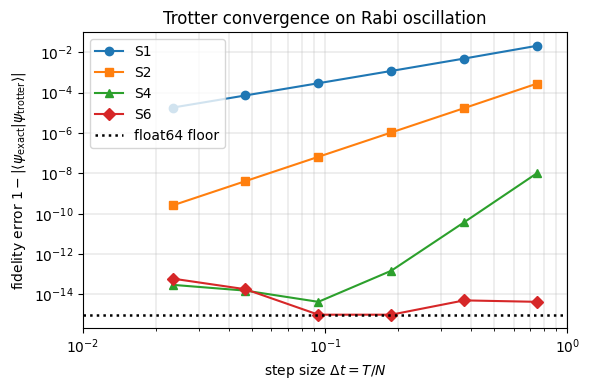

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
markers = {"S1": "o", "S2": "s", "S4": "^", "S6": "D"}
for name in all_names:
    ax.loglog(dts, errors[name], marker=markers[name], label=name)
ax.axhline(1e-15, color="black", linestyle=":", linewidth=1.8, label="float64 floor")
ax.set_xlim(1e-2, 1e0)
ax.set_xlabel(r"step size $\Delta t = T / N$")
ax.set_ylabel(
    r"fidelity error $1 - |\langle \psi_{\rm exact} | \psi_{\rm trotter} \rangle|$"
)
ax.set_title("Trotter convergence on Rabi oscillation")
ax.grid(True, which="both", linewidth=0.3)
ax.legend()
fig.tight_layout()
plt.show()

The lines on the plot have slopes $\approx 2, 4, 8$, matching the
fidelity-error orders in the table above. $S_4$ hits the float64 floor
already at $N = 16$; $S_6$ is at the floor across the entire sweep, so its
line appears flat (the expected $\Delta t^{12}$ slope is not resolvable on
this 1-qubit problem in double precision).

In practice, the approximation order is chosen by balancing the required
accuracy against the computational cost. Higher orders improve accuracy, but
they also increase the number of quantum gates per step. This is especially
important on NISQ devices, where deeper circuits are more strongly affected
by hardware noise.

## Summary

In this notebook, we:

- Learned that the Suzuki–Trotter decomposition approximates time evolution
  under noncommuting Hamiltonian terms, from the first-order Lie–Trotter
  formula to recursively constructed higher even orders.
- Introduced Qamomile's `trotterized_time_evolution`, which applies the
  selected product formula from a list of Hamiltonian terms, an order, a total
  evolution time, and a number of Trotter steps.
- Numerically compared the approximations with the exact Rabi evolution and
  confirmed the expected convergence behavior for the tested orders, up to
  the float64 precision floor.